# Portfolio Optimization

Calculate risk metrics and optimize portfolio weights using Sharpe ratio maximization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Load data
price_df = pd.read_csv('price_data.csv', index_col=0, parse_dates=True)
returns = pd.read_csv('returns_data.csv', index_col=0, parse_dates=True)
stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "XOM", "NVDA"]

In [3]:
# Calculate risk metrics
mean_returns = returns[stocks].mean()
cov_matrix = returns[stocks].cov()
volatility = returns[stocks].std()

print("Risk Metrics:")
print("\nMean Returns (Daily):")
print(mean_returns.round(6))
print(f"\nAnnualized Mean Returns:")
print((mean_returns * 252).round(4))
print(f"\nAnnualized Volatility:")
print((volatility * np.sqrt(252)).round(4))

Risk Metrics:

Mean Returns (Daily):
AAPL     0.000786
MSFT     0.001039
GOOGL    0.000880
AMZN     0.001508
JPM      0.000752
XOM     -0.000051
NVDA     0.002563
dtype: float64

Annualized Mean Returns:
AAPL     0.1981
MSFT     0.2618
GOOGL    0.2218
AMZN     0.3799
JPM      0.1895
XOM     -0.0130
NVDA     0.6458
dtype: float64

Annualized Volatility:
AAPL     0.2317
MSFT     0.2256
GOOGL    0.2203
AMZN     0.2895
JPM      0.2039
XOM      0.1750
NVDA     0.3548
dtype: float64


In [4]:
# Define optimization functions
def portfolio_performance(weights, mean_ret, cov_mat, rf_rate=0.02/252):
    """Calculate portfolio return, volatility, and Sharpe ratio"""
    portfolio_return = np.sum(mean_ret * weights)
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
    sharpe_ratio = (portfolio_return - rf_rate) / portfolio_std if portfolio_std > 0 else 0
    return portfolio_return, portfolio_std, sharpe_ratio

def neg_sharpe(weights, mean_ret, cov_mat):
    """Negative Sharpe ratio for optimization (minimize)"""
    return -portfolio_performance(weights, mean_ret, cov_mat)[2]

print("✓ Optimization functions defined")

✓ Optimization functions defined


In [5]:
# Optimization constraints and bounds
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}  # Weights sum to 1
bounds = tuple((0, 1) for _ in range(len(stocks)))  # 0 <= weight <= 1
init_guess = np.array([1/len(stocks)] * len(stocks))  # Equal weight starting point

print(f"Optimization constraints:")
print(f"  • Number of assets: {len(stocks)}")
print(f"  • Sum of weights = 1 (fully invested)")
print(f"  • Long-only (no short selling)")

Optimization constraints:
  • Number of assets: 7
  • Sum of weights = 1 (fully invested)
  • Long-only (no short selling)


In [6]:
# Optimize for maximum Sharpe ratio
result = minimize(
    neg_sharpe,
    init_guess,
    args=(mean_returns, cov_matrix),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

opt_weights = result.x
opt_return, opt_std, opt_sharpe = portfolio_performance(opt_weights, mean_returns, cov_matrix)

print("\nOptimized Portfolio:")
print(f"  • Optimization successful: {result.success}")
print(f"  • Daily Return: {opt_return:.6f}")
print(f"  • Daily Volatility: {opt_std:.6f}")
print(f"  • Sharpe Ratio: {opt_sharpe:.4f}")
print(f"\nAnnualized:")
print(f"  • Return: {opt_return*252:.4f}")
print(f"  • Volatility: {opt_std*np.sqrt(252):.4f}")


Optimized Portfolio:
  • Optimization successful: True
  • Daily Return: 0.001943
  • Daily Volatility: 0.015110
  • Sharpe Ratio: 0.1233

Annualized:
  • Return: 0.4895
  • Volatility: 0.2399


In [7]:
# Optimal weights
print("\nOptimal Portfolio Allocation:")
print("-"*40)
for stock, weight in zip(stocks, opt_weights):
    print(f"{stock:<10} {weight:>8.2%}")
print("-"*40)
print(f"Total:      {np.sum(opt_weights):>8.2%}")


Optimal Portfolio Allocation:
----------------------------------------
AAPL          1.02%
MSFT         11.65%
GOOGL         0.00%
AMZN         31.76%
JPM           4.93%
XOM           0.00%
NVDA         50.64%
----------------------------------------
Total:       100.00%


In [8]:
# Generate random portfolios for efficient frontier
np.random.seed(42)
num_portfolios = 10000
results = np.zeros((3, num_portfolios))

print(f"Generating {num_portfolios} random portfolios...")
for i in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)
    
    port_return = np.sum(mean_returns * weights) * 252
    port_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
    port_sharpe = (port_return - 0.02) / port_std if port_std > 0 else 0
    
    results[0, i] = port_std
    results[1, i] = port_return
    results[2, i] = port_sharpe

print("✓ Complete")

Generating 10000 random portfolios...
✓ Complete


In [9]:
# Find optimal portfolios from random sampling
max_sharpe_idx = np.argmax(results[2])
min_vol_idx = np.argmin(results[0])

max_sharpe_return = results[1, max_sharpe_idx]
max_sharpe_std = results[0, max_sharpe_idx]
min_vol_return = results[1, min_vol_idx]
min_vol_std = results[0, min_vol_idx]

print("Best Portfolios from Random Sampling:")
print("\nMax Sharpe Ratio:")
print(f"  • Return: {max_sharpe_return:.4f}")
print(f"  • Volatility: {max_sharpe_std:.4f}")
print(f"  • Sharpe: {results[2, max_sharpe_idx]:.4f}")
print("\nMin Volatility:")
print(f"  • Return: {min_vol_return:.4f}")
print(f"  • Volatility: {min_vol_std:.4f}")
print(f"  • Sharpe: {results[2, min_vol_idx]:.4f}")

Best Portfolios from Random Sampling:

Max Sharpe Ratio:
  • Return: 0.4237
  • Volatility: 0.2104
  • Sharpe: 1.9185

Min Volatility:
  • Return: 0.1516
  • Volatility: 0.1441
  • Sharpe: 0.9135


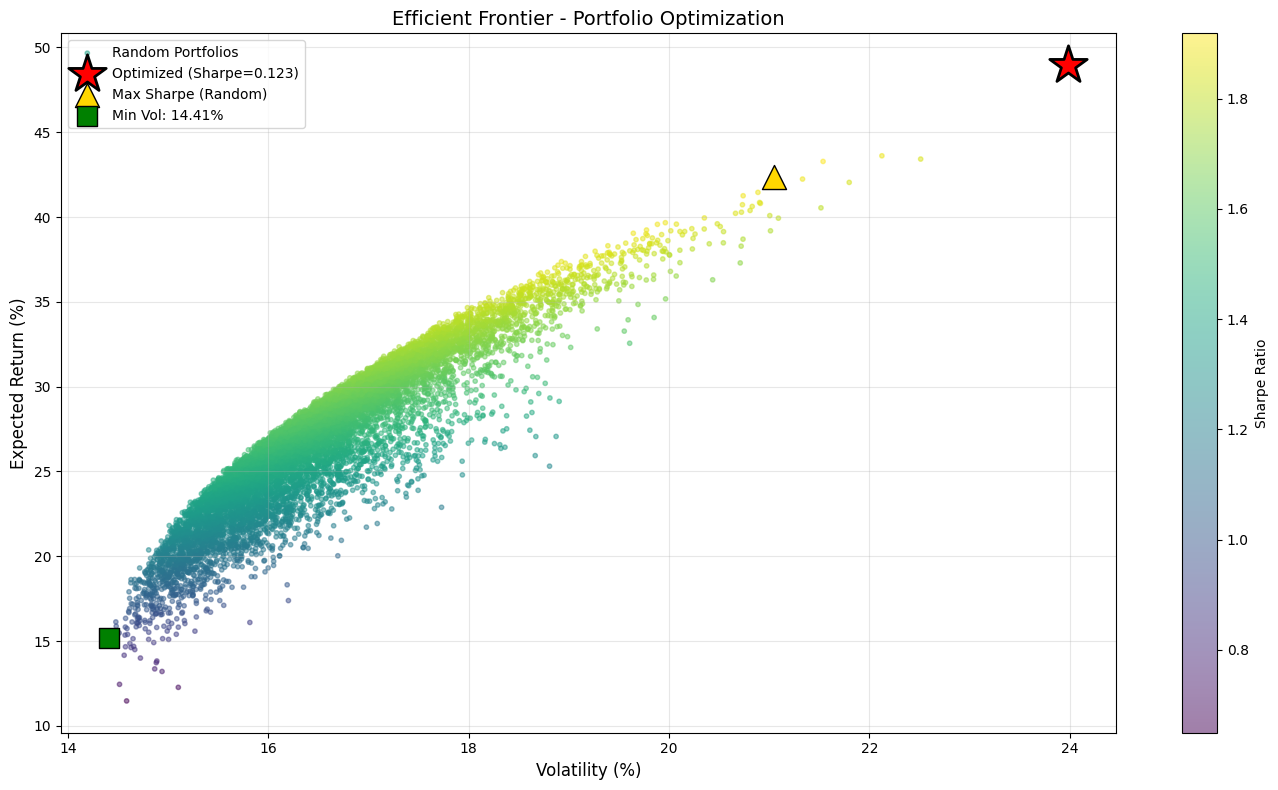

In [10]:
# Efficient frontier visualization
plt.figure(figsize=(14, 8))

# Scatter plot of random portfolios
scatter = plt.scatter(results[0,:]*100, results[1,:]*100, c=results[2,:], 
                       cmap='viridis', alpha=0.5, s=10, label='Random Portfolios')

# Optimized portfolio (from scipy)
plt.scatter(opt_std*np.sqrt(252)*100, opt_return*252*100, marker='*', color='red', s=800, 
           label=f'Optimized (Sharpe={opt_sharpe:.3f})', edgecolors='black', linewidth=2, zorder=5)

# Max Sharpe from random sampling
plt.scatter(max_sharpe_std*100, max_sharpe_return*100, marker='^', color='gold', s=300, 
           label=f'Max Sharpe (Random)', edgecolors='black', linewidth=1, zorder=4)

# Min volatility
plt.scatter(min_vol_std*100, min_vol_return*100, marker='s', color='green', s=200, 
           label=f'Min Vol: {min_vol_std*100:.2f}%', edgecolors='black', linewidth=1, zorder=4)

cbar = plt.colorbar(scatter, label='Sharpe Ratio')
plt.xlabel('Volatility (%)', fontsize=12)
plt.ylabel('Expected Return (%)', fontsize=12)
plt.title('Efficient Frontier - Portfolio Optimization', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

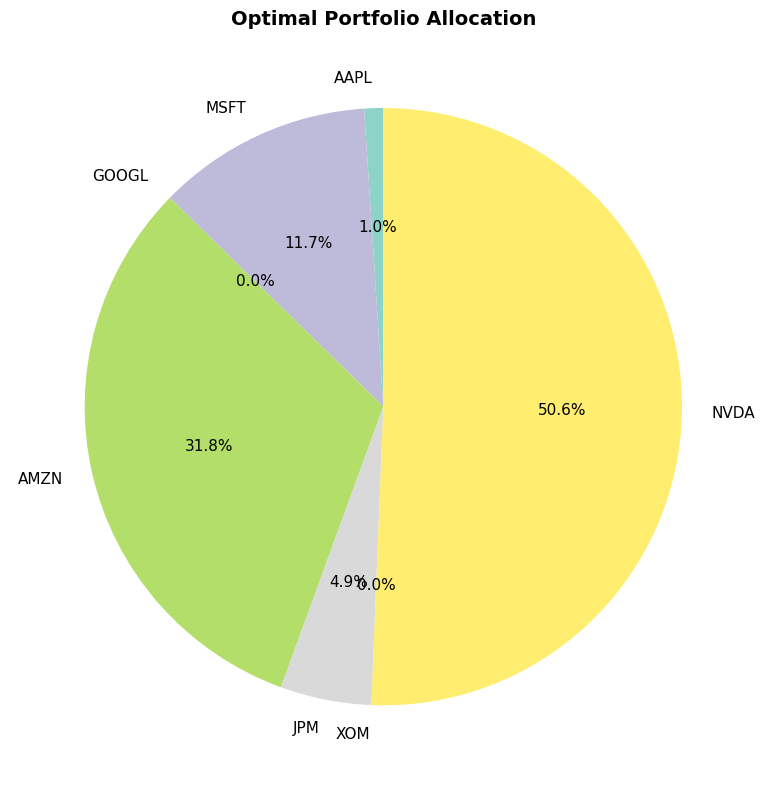

In [11]:
# Allocation pie chart
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(stocks)))
wedges, texts, autotexts = ax.pie(opt_weights, labels=stocks, autopct='%1.1f%%', 
                                    colors=colors, startangle=90, textprops={'fontsize': 11})
ax.set_title('Optimal Portfolio Allocation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
print("\n✓ Portfolio Optimization Complete")
print(f"\nOptimized weights and efficient frontier generated")


✓ Portfolio Optimization Complete

Optimized weights and efficient frontier generated
